In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import stan

import nest_asyncio
nest_asyncio.apply()

import logging
logging.getLogger().setLevel(logging.ERROR)

/home/vivek/Documents/.pystan/lib/python3.12/site-packages/stan/plugins.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
## Output folder for figures
out_dir = Path("output")
out_dir.mkdir(exist_ok=True)

In [3]:
## Load PCF curves and peak table
pcf_all = pd.read_csv('processed_data/pcf_curve_ALL.csv')
peaks = pd.read_csv('processed_data/pcf_peak_table_ALL.csv')

pcf_all['date'] = pd.to_datetime(pcf_all['date'])
peaks['date'] = pd.to_datetime(peaks['date'])

pcf_all.head()

,r,g,lek_id,data_label,date,n_points,r_max_used,ref_median_nn
0,5.224499,0.048594,TalChhapar_TC,12OCT,2012-10-01,162,65.718693,16.429673
1,5.499472,0.057370,TalChhapar_TC,12OCT,2012-10-01,162,65.718693,16.429673
2,5.774446,0.067809,TalChhapar_TC,12OCT,2012-10-01,162,65.718693,16.429673
3,6.049419,0.078164,TalChhapar_TC,12OCT,2012-10-01,162,65.718693,16.429673
4,6.324393,0.088378,TalChhapar_TC,12OCT,2012-10-01,162,65.718693,16.429673


In [4]:
## Create consistent integer encodings for sites
site_lookup = {lek: i+1 for i,lek in enumerate(sorted(pcf_all['lek_id'].unique()))}
unique_dates = sorted(pcf_all['date'].unique())

pcf_all['site_id'] = pcf_all['lek_id'].map(site_lookup)
peaks['site_id'] = peaks['lek_id'].map(site_lookup)

In [5]:
## Isolate a row for each PCF curve to count peaks
cols = ['lek_id', 'site_id', 'date', 'n_points']
curves_base = pcf_all[cols].drop_duplicates().sort_values(['lek_id', 'date']).reset_index(drop=True)

In [6]:
## For each curve (lek × date), get the peak-count category; curves with no detected peaks become 0
peaks_count = peaks.groupby(['lek_id', 'date'], as_index=False)['n_peaks'].max().rename(columns={'n_peaks': 'n_peaks'})
n_peaks_df = curves_base.merge(peaks_count, on=['lek_id', 'date'], how='left').assign(n_peaks=lambda d: d['n_peaks'].fillna(0).astype(int))

In [7]:
## Factor ordering + labels
lek_order = ['TalChhapar_TC', 'Velavadar_LEK1', 'Velavadar_LEK2']
lek_labels = {'TalChhapar_TC': 'Tal Chhapar', 'Velavadar_LEK1': 'Velavadar Lek 1','Velavadar_LEK2': 'Velavadar Lek 2'}

n_peaks_df['lek_id'] = (pd.Categorical(n_peaks_df['lek_id'],categories=lek_order,ordered=True).rename_categories(lek_labels))

## Map site ID to lek labels
site_to_lek = n_peaks_df[['site_id', 'lek_id']].drop_duplicates().sort_values('site_id')
site_to_lek = dict(zip(site_to_lek['site_id'].astype(int), site_to_lek['lek_id']))

In [8]:
## Colour palettes
fill_cols = {'Tal Chhapar': '#B5542D', 'Velavadar Lek 1': '#2F7F7B', 'Velavadar Lek 2': '#6FB7B3'}
point_cols = {'Tal Chhapar': '#D97A52', 'Velavadar Lek 1': '#1F5F5B', 'Velavadar Lek 2': '#8FD0CC'}
line_cols = {'Tal Chhapar': '#B5542D', 'Velavadar Lek 1': '#2F7F7B', 'Velavadar Lek 2': '#6FB7B3'}

lek_labels_ordered = n_peaks_df['lek_id'].cat.categories.tolist()

In [9]:
## Model the number of peaks for each lek
## Ordered logistic model: latent "structure" score per site and cutpoints define peak count categories
n_peaks_mod = """
data {
    int<lower=1> n_points;
    int<lower=1> n_sites;
    int<lower=2> max_peaks;

    array[n_points] int<lower=1,upper=n_sites> site_id;
    array[n_points] int<lower=1,upper=max_peaks> y;
}

parameters {
    real alpha;
    vector[n_sites] site_eff_raw;
    ordered[max_peaks-1] c;
}

transformed parameters {
    vector[n_sites] site_eff;
    site_eff = site_eff_raw - mean(site_eff_raw);
}

model {
    alpha ~ normal(0, 1);
    site_eff_raw ~ normal(0, 1);
    c ~ normal(0, 2);

    for (n in 1:n_points) {
        y[n] ~ ordered_logistic(alpha + site_eff[site_id[n]], c);
    }
}

generated quantities {
    real diff_T_V1 = site_eff[1] - site_eff[2];
    real diff_V1_V2 = site_eff[2] - site_eff[3];
    real diff_T_V2 = site_eff[1] - site_eff[3];

    array[n_sites] vector[max_peaks] p_site;

    for (s in 1:n_sites) {
        real eta = alpha + site_eff[s];

        // cumulative probs: P(Y <= k)
        vector[max_peaks - 1] F;
        for (k in 1:(max_peaks - 1)) {
            F[k] = inv_logit(c[k] - eta);
        }

        // category probs from cumulative probs
        p_site[s][1] = F[1];
        for (k in 2:(max_peaks - 1)) {
            p_site[s][k] = F[k] - F[k - 1];
        }
        p_site[s][max_peaks] = 1 - F[max_peaks - 1];
    }
}
"""

In [10]:
data_peaks = {
    'n_points': len(n_peaks_df),
    'n_sites': int(n_peaks_df['site_id'].nunique()),
    'max_peaks': 4,
    'site_id': n_peaks_df['site_id'].astype(int).to_numpy(),
    'y': n_peaks_df['n_peaks'].astype(int).to_numpy() + 1
}

posterior = stan.build(n_peaks_mod, data=data_peaks)
fit = posterior.sample(num_chains=4, num_warmup=1000, num_samples=1000)

Building: found in cache, done.
Sampling:   0%
Sampling:   8% (600/8000)
Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x7d390414b0c0> is already entered
Sampling:  32% (2600/8000)
Sampling:  58% (4600/8000)
Sampling:  82% (6600/8000)
Sampling: 100% (8000/8000)
Sampling: 100% (8000/8000), done.
Messages received during sampling:
  Gradient evaluation took 5.5e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.55 seconds.
  Adjust your expectations accordingly!
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 3 is inf, but should be greater than the previous element, inf

In [11]:
## Posterior distributions of latent structure on the leks
site_eff = fit['site_eff']
tal = site_eff[0, :]
vel1 = site_eff[1, :]
vel2 = site_eff[2, :]

## Difference in latent structure between Tal Chhapar and the two Velavadar leks
delta1 = tal - vel1
delta2 = tal - vel2

In [12]:
## Probability of the Tal Chhapar lek having more structure
pr_v1 = (delta1 > 0).mean()
pr_v2 = (delta2 > 0).mean()

## Median + CI of difference in structure between the two locations
med_diff1 = np.median(delta1)
ci_diff1 = np.quantile(delta1, [0.025, 0.975])
med_diff2 = np.median(delta2)
ci_diff2 = np.quantile(delta2, [0.025, 0.975])

## Odds ratio of the median difference in structure
or_med1 = np.exp(med_diff1)
or_med2 = np.exp(med_diff2)

print(pr_v1, pr_v2)
print(med_diff1, ci_diff1, med_diff2, ci_diff2)
print(or_med1, or_med2)

0.99775 0.99625
1.8788423604281899 [0.51038874 3.33341879] 1.963381026622339 [0.52837462 3.54505926]
6.545922655206811 7.1233707021487565


In [13]:
## Empirical probability of each peak count category per lek (for plotting against posterior)
peak_categories = np.sort(n_peaks_df['n_peaks'].unique())

peaks_counts = n_peaks_df[['lek_id', 'date', 'n_peaks']].drop_duplicates().copy()
peak_proportions = peaks_counts.assign(n_peaks=lambda d: d['n_peaks'].astype(int)).groupby(['lek_id', 'n_peaks'], observed=False).size().rename('count').reset_index()
peak_proportions['prop'] = peak_proportions.groupby('lek_id', observed=False)['count'].transform(lambda x: x / x.sum())

In [14]:
n_sites_post, k_post, n_draws = fit['p_site'].shape
assert k_post == len(n_peaks_df['n_peaks'].unique()), f'p_site has {k_post} categories, expected {max_peaks}'

## Summarize posterior p_site per site × category
post_rows = []
for s in range(1, n_sites_post+1):
    for k in range(1, k_post+1):
        draws = fit['p_site'][s-1, k-1, :]
        post_rows.append({
            'site_id': s, 'lek_id': site_to_lek.get(s), 'n_peaks': k-1, 
            'mean': float(np.mean(draws)), 'lo': float(np.quantile(draws, 0.025)), 'hi': float(np.quantile(draws, 0.975))})
        
post = pd.DataFrame(post_rows)

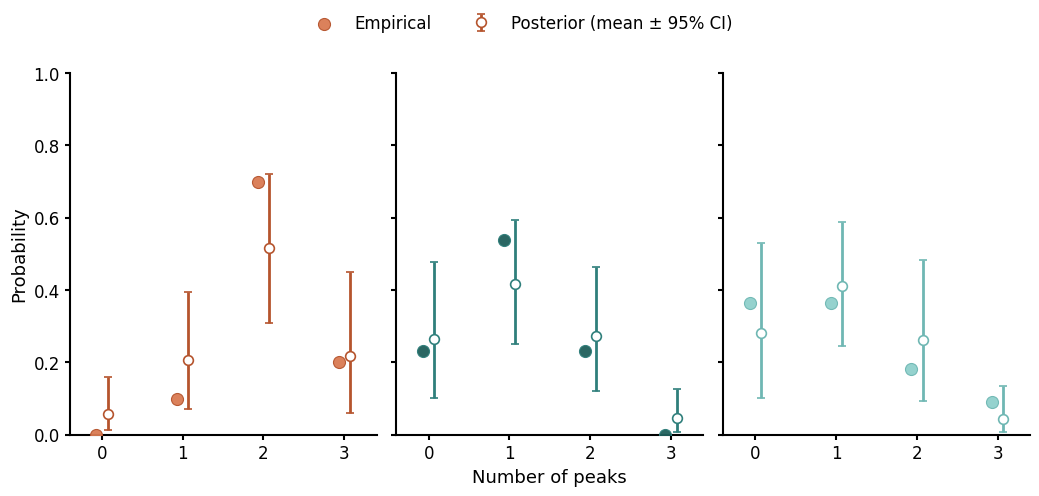

In [15]:
## Plot empirical category probabilities against posterior (mean ± 95% CI)
fig, axes = plt.subplots(1, 3, figsize=(10.5, 5), sharey=True)

x_offset = 0.07  # small dodge so empirical and posterior don't overlap

for ax, lek in zip(axes, lek_labels_ordered):
    empirical_data = peak_proportions[peak_proportions['lek_id'] == lek].sort_values('n_peaks')
    model_posteriors = post[post['lek_id'] == lek].sort_values('n_peaks')

    col_fill = fill_cols[str(lek)]
    col_point = point_cols[str(lek)]

    # Empirical proportions (filled markers)
    ax.scatter(empirical_data['n_peaks'] - x_offset, empirical_data['prop'], s=75,
               facecolor=col_point, edgecolor=col_fill,
               linewidth=0.8, alpha=0.95, zorder=4,
               label="Empirical" if ax is axes[0] else None)

    # Posterior mean + 95% CI (hollow markers + error bars)
    ax.errorbar(model_posteriors['n_peaks'] + x_offset, model_posteriors['mean'],
                yerr=[model_posteriors['mean'] - model_posteriors['lo'], model_posteriors['hi'] - model_posteriors['mean']],
                fmt='o', markersize=7, mfc='white', mec=col_fill, mew=1.2,
                color=col_fill, ecolor=col_fill, elinewidth=2, capsize=3, zorder=3,
                label="Posterior (mean ± 95% CI)" if ax is axes[0] else None)

    ax.set_xticks(peak_categories)
    ax.set_xlim(-0.4, peak_categories.max() + 0.4)
    ax.set_ylim(0, 1)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

axes[1].set_xlabel('Number of peaks', fontsize=13)
axes[0].set_ylabel('Probability', fontsize=13)

# Single legend for the whole figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False, fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig(out_dir/'npeaks_structure.png', dpi=300, bbox_inches='tight')

In [ ]:
# --- Ready dataframe to model the curvature of peaks on the pcf curves
# For curvature, we only keep actual peak rows (non-missing peak_curvature)
peaks_only = peaks.dropna(subset=['peak_curvature']).copy()

# Attach curve-level metadata (site_id, time_id, n_points, n_peaks) to each peak row
peaks_only = peaks_only.merge(
    n_peaks_df[['lek_id', 'date', 'site_id', 'time_id'] + (['n_points'] if 'n_points' in n_peaks_df.columns else []) + ['n_peaks'],
    on=['lek_id', 'date'],
    how='left'
)

curvature_df = peaks_only.sort_values(['lek_id', 'date', 'r_peak']).copy()
curvature_df['peak_num'] = curvature_df.groupby(['lek_id', 'date']).cumcount() + 1

curvature_df['log_curvature'] = np.log(curvature_df['peak_curvature'])
curvature_df = curvature_df[['lek_id', 'site_id', 'date', 'time_id', 'n_points', 'n_peaks', 'peak_num', 
                             'r_peak', 's_peak', 'peak_prominence', 'peak_curvature', 'log_curvature']].reset_index(drop=True)

In [ ]:
curvature_df = curvature_df.merge(curves, on=['lek_id', 'date'], how='left')

## Standardize peak_num for nicer sampling / interpretation
curvature_df['peak_num_z'] = (curvature_df['peak_num'] - curvature_df['peak_num'].mean()) / curvature_df['peak_num'].std(ddof=0)

In [ ]:
curvature_mod = """
data {
  int<lower=1> n_points;
  int<lower=1> n_sites;
  int<lower=1> n_pcf_curves;

  array[n_points] int<lower=1, upper=n_sites> site_id;
  array[n_points] int<lower=1, upper=n_pcf_curves> curve_id;

  vector[n_points] peak_num_z;                    // standardized peak number
  vector[n_points] log_curvature;                 // log(peak_curvature)
}

parameters {
  real alpha;                               // grand intercept (log scale)

  // Site-level fixed intercepts and optional slope deviations
  vector[n_sites] site_int_raw;
  real<lower=0> sigma_site_int;

  real beta_peak;                           // global effect of peak number (expect < 0)

  vector[n_sites] site_slope_raw;                 // site-specific slope deviations (optional)
  real<lower=0> sigma_site_slope;           // shrinkage for site slope deviations

  // Curve-level random intercepts and optional random slopes
  vector[n_pcf_curves] curve_int_raw;
  real<lower=0> sigma_curve_int;

  // Observation noise on log scale
  real<lower=0> sigma;
}

transformed parameters {
  vector[n_sites] site_int = site_int_raw * sigma_site_int;

  // site-specific slopes around global beta_peak
  vector[n_sites] site_slope = beta_peak + site_slope_raw * sigma_site_slope;
}

model {
  // Priors (weakly informative)
  alpha ~ normal(0, 5);                     // wide on log scale

  site_int_raw ~ normal(0, 1);
  sigma_site_int ~ normal(0, 2);

  beta_peak ~ normal(0, 1);                 // with peak_num_z, slope ~ O(1)

  site_slope_raw ~ normal(0, 1);
  sigma_site_slope ~ normal(0, 1);

  sigma_curve_int ~ normal(0, 2);

  sigma ~ normal(0, 1);

  // Likelihood
  for (n in 1:n_points) {
    real mu = alpha + site_int[site_id[n]] + beta_peak * peak_num_z[n];

    log_curvature[n] ~ normal(mu, sigma);
  }
}

generated quantities {
  real diff_int_2_1 = site_int[2] - site_int[1];
  real diff_int_3_1 = site_int[3] - site_int[1];
  real diff_int_3_2 = site_int[3] - site_int[2];

  // Geometric-mean ratios for curvature (multiplicative)
  real gmr_int_2_1 = exp(diff_int_2_1);
  real gmr_int_3_1 = exp(diff_int_3_1);
  real gmr_int_3_2 = exp(diff_int_3_2);

  // Peak-number slope per site (on standardized scale)
  // Interpretable as multiplicative change per +1 SD in peak_num
  vector[S] slope_mult;
  for (s in 1:n_sites) slope_mult[s] = exp(site_slope[s]);
}
"""

data_curvature = {
    'n_points': len(curvature_df),
    'n_sites': int(curvature_df['site_id'].nunique()),
    'n_pcf_curves': int(curvature_df['curve_id'].nunique()),
    'site_id': curvature_df['site_id'].astype(int).to_numpy(),
    'curve_id': curvature_df['curve_id'].astype(int).to_numpy(),
    'peak_num_z': curvature_df['peak_num_z'].astype(float).to_numpy(),
    'log_curvature': curvature_df['log_curvature'].astype(float).to_numpy(),
}

posterior = stan.build(curvature_mod, data=data_curvature)
fit = posterior.sample(num_chains=4, num_warmup=1000, num_samples=1000)

In [14]:
n_peaks_df.groupby("lek_id")["n_peaks"].agg(["mean","var"])

,mean,var
lek_id,,
TalChhapar_TC,2.100000,0.322222
Velavadar_LEK1,1.300000,0.233333
Velavadar_LEK2,1.571429,0.619048
